In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import subprocess
from scipy.stats import chisquare
import os
import glob

# import scipy.stats as stats

In [2]:
%load_ext autoreload

%autoreload 2
import pandas as pd
import numpy as np
%aimport Variant_analysis_helper_functions


#import protfasta
import os

---
# Building table

In [3]:
# Only keep TFs with ADs
all_TFs = pd.read_csv("../outputs/all_TFs_table_proteins_activators.txt", sep = "\t")
activator_TF_ENSTs = set(all_TFs["ENST"])
activator_TF_ENSTs

{'ENST00000008391',
 'ENST00000056233',
 'ENST00000078445',
 'ENST00000162391',
 'ENST00000177694',
 'ENST00000201031',
 'ENST00000206513',
 'ENST00000216037',
 'ENST00000216513',
 'ENST00000217026',
 'ENST00000219905',
 'ENST00000221452',
 'ENST00000221996',
 'ENST00000222122',
 'ENST00000222305',
 'ENST00000222718',
 'ENST00000222728',
 'ENST00000223357',
 'ENST00000226067',
 'ENST00000226247',
 'ENST00000228641',
 'ENST00000228644',
 'ENST00000228682',
 'ENST00000228741',
 'ENST00000229307',
 'ENST00000231656',
 'ENST00000234392',
 'ENST00000239165',
 'ENST00000239174',
 'ENST00000239243',
 'ENST00000239461',
 'ENST00000239882',
 'ENST00000239938',
 'ENST00000240335',
 'ENST00000241001',
 'ENST00000241651',
 'ENST00000242057',
 'ENST00000242159',
 'ENST00000242261',
 'ENST00000242462',
 'ENST00000244745',
 'ENST00000245414',
 'ENST00000245479',
 'ENST00000246229',
 'ENST00000246672',
 'ENST00000247219',
 'ENST00000247930',
 'ENST00000248071',
 'ENST00000249499',
 'ENST00000250003',


In [5]:
# Only keep ENSTs which have variants in domains
ENSTs_w_vars = glob.glob("../outputs/mutations/domains_expanded_iWES_v2_variants_snv_classified/*")
ENSTs_w_vars = [s.split("/")[-1].split(".")[0] for s in ENSTs_w_vars]
ENSTs_w_vars

['ENST00000259803',
 'ENST00000443427',
 'ENST00000234392',
 'ENST00000162391',
 'ENST00000356073',
 'ENST00000503201',
 'ENST00000283921',
 'ENST00000377687',
 'ENST00000508793',
 'ENST00000302754',
 'ENST00000595883',
 'ENST00000241651',
 'ENST00000306268',
 'ENST00000393716',
 'ENST00000617811',
 'ENST00000645831',
 'ENST00000647767',
 'ENST00000273153',
 'ENST00000222122',
 'ENST00000312156',
 'ENST00000078445',
 'ENST00000222718',
 'ENST00000308873',
 'ENST00000397410',
 'ENST00000348066',
 'ENST00000447654',
 'ENST00000695966',
 'ENST00000374012',
 'ENST00000468660',
 'ENST00000427363',
 'ENST00000379044',
 'ENST00000368607',
 'ENST00000443632',
 'ENST00000636215',
 'ENST00000371222',
 'ENST00000242159',
 'ENST00000264834',
 'ENST00000677301',
 'ENST00000376983',
 'ENST00000350777',
 'ENST00000259021',
 'ENST00000393067',
 'ENST00000358470',
 'ENST00000246672',
 'ENST00000686138',
 'ENST00000396862',
 'ENST00000366987',
 'ENST00000367284',
 'ENST00000317011',
 'ENST00000405666',


In [6]:
pd.read_csv("../outputs/mutations/cds_expanded_iWES_v2_variants_snv_classified/ENST00000434704.bed", sep = "\t", header = None).head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,17,49991523,49991524,ENST00000434704,-1,17,49991523,49991524,A,G,0.000005,V,A,No-Syn
1,17,49991527,49991528,ENST00000434704,-1,17,49991527,49991528,C,T,0.000089,A,T,No-Syn
2,17,49991530,49991531,ENST00000434704,-1,17,49991530,49991531,C,T,0.000009,G,R,No-Syn
3,17,49991530,49991531,ENST00000434704,-1,17,49991530,49991531,C,G,0.000005,G,R,No-Syn
4,17,49991534,49991535,ENST00000434704,-1,17,49991534,49991535,G,T,0.000033,N,K,No-Syn


In [7]:
d_domains = "../outputs/mutations/domains_expanded_iWES_v2_variants_snv_classified/"
files = os.listdir(d_domains)
ENST_codes = [f.replace(".bed", "") for f in files if f !='.ipynb_checkpoints']

# Only keep SFARI TFs
uniprotID_ENST_mapping = pd.read_csv("../../data/SFARI_TFs_with_ENST_corrected.csv")
uniprotID_ENST_mapping = uniprotID_ENST_mapping[["uniprotID", "ENST"]]
uniprotID_ENST_mapping["ENST"] = uniprotID_ENST_mapping["ENST"].str.split(".").str[0]
uniprotID_ENST_mapping_dict= dict(zip(uniprotID_ENST_mapping["ENST"], uniprotID_ENST_mapping["uniprotID"]))
uniprotID_ENST_mapping_dict['ENST00000434704'] = 'O60479'

# ENSTs to keep, SK 11/18/24
ENST_codes = set(ENST_codes) & set(uniprotID_ENST_mapping_dict.keys()) & set(activator_TF_ENSTs) & set(ENSTs_w_vars)



In [8]:
# Only keep ENSTs with at least one var
ENST_codes_to_use = []

for ENST_code in ENST_codes:
    with open(d_domains + ENST_code + ".bed", 'r') as fp:
        lines = len(fp.readlines())
        if lines == 0:
            print(ENST_code)
        else:
            ENST_codes_to_use.append(ENST_code)

In [9]:
len(ENST_codes_to_use)

46

In [10]:
ENST_codes_to_use

['ENST00000377142',
 'ENST00000389506',
 'ENST00000282549',
 'ENST00000239243',
 'ENST00000309446',
 'ENST00000339562',
 'ENST00000561208',
 'ENST00000056233',
 'ENST00000367265',
 'ENST00000288319',
 'ENST00000303329',
 'ENST00000374690',
 'ENST00000372583',
 'ENST00000318003',
 'ENST00000437473',
 'ENST00000265340',
 'ENST00000380013',
 'ENST00000312233',
 'ENST00000592199',
 'ENST00000355311',
 'ENST00000348332',
 'ENST00000355995',
 'ENST00000373294',
 'ENST00000262518',
 'ENST00000335670',
 'ENST00000356073',
 'ENST00000246672',
 'ENST00000428368',
 'ENST00000262238',
 'ENST00000241001',
 'ENST00000331340',
 'ENST00000342988',
 'ENST00000317216',
 'ENST00000348066',
 'ENST00000341099',
 'ENST00000250916',
 'ENST00000403491',
 'ENST00000377022',
 'ENST00000264637',
 'ENST00000395324',
 'ENST00000359486',
 'ENST00000373036',
 'ENST00000379044',
 'ENST00000358127',
 'ENST00000315869',
 'ENST00000434704']

In [11]:
#slower to run
SFARI_TFs = pd.read_csv("../../data/SFARI_TFs_with_ENST.csv")

output = Variant_analysis_helper_functions.generate_df_parallel_progress(ENST_codes_to_use, 0, 1, 
                                                       domain_types = ["AD", "DBD", "RD"], print_output = True,
                                                      variant_filename = "expanded_iWES_v2_variants")

Processing ENST codes: 100%|██████████| 46/46 [00:02<00:00, 20.47it/s]

5 ENST00000309446
6 ENST00000339562
3 ENST00000282549
1 ENST00000377142
4 ENST00000239243
2 ENST00000389506
7 ENST00000561208
8 ENST00000056233
9 ENST00000367265
10 ENST00000288319
11 ENST00000303329
12 ENST00000374690
13 ENST00000372583
14 ENST00000318003
15 ENST00000437473
16 ENST00000265340
17 ENST00000380013
18 ENST00000312233
19 ENST00000592199
20 ENST00000355311
21 ENST00000348332
22 ENST00000355995
23 ENST00000373294
24 ENST00000262518
25 ENST00000335670
26 ENST00000356073
27 ENST00000246672
28 ENST00000428368
29 ENST00000262238
30 ENST00000241001
31 ENST00000331340
32 ENST00000342988
33 ENST00000317216
34 ENST00000348066
35 ENST00000341099
36 ENST00000250916
37 ENST00000403491
38 ENST00000377022
39 ENST00000264637
40 ENST00000395324
41 ENST00000359486
42 ENST00000373036
43 ENST00000379044
44 ENST00000358127
45 ENST00000315869
46 ENST00000434704


In [12]:
# #slower to run
# SFARI_TFs = pd.read_csv("../../data/SFARI_TFs_with_ENST.csv")

# output = Variant_analysis_helper_functions.generate_df(ENST_codes_to_use, uniprotID_ENST_mapping_dict, 0, 1, 
#                                                        domain_types = ["AD", "DBD", "RD"], print_output = True,
#                                                       variant_filename = "expanded_iWES_v3_variants")

In [13]:
output_saved = output.copy(deep = True)
output_saved

,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop
0,P35548,804,126,0.156716,102,14,0.137255,171,15,0.087719,0,0,NaN
1,P32242,1065,108,0.101408,549,67,0.122040,171,9,0.052632,0,0,NaN
2,P43354,1797,159,0.088481,318,16,0.050314,210,9,0.042857,0,116,inf
3,Q03164,11910,985,0.082704,420,24,0.057143,144,5,0.034722,0,14,inf
4,O14770,1434,137,0.095537,414,67,0.161836,174,4,0.022989,0,6,inf
5,O95096,822,116,0.141119,162,35,0.216049,171,10,0.058480,0,32,inf
6,O75840,909,75,0.082508,300,27,0.090000,219,5,0.022831,0,28,inf
7,P10275,2763,219,0.079262,2259,182,0.080567,210,9,0.042857,0,88,inf
8,Q9HBZ2,2154,217,0.100743,582,49,0.084192,162,8,0.049383,0,26,inf
9,P11308,1440,128,0.088889,573,54,0.094241,240,5,0.020833,0,94,inf


In [14]:
# Removing rows without ADs
output = output.dropna(subset = ["AD_missense_prop"])
output = output.reset_index(drop = True)
output

,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop
0,P35548,804,126,0.156716,102,14,0.137255,171,15,0.087719,0,0,NaN
1,P32242,1065,108,0.101408,549,67,0.122040,171,9,0.052632,0,0,NaN
2,P43354,1797,159,0.088481,318,16,0.050314,210,9,0.042857,0,116,inf
3,Q03164,11910,985,0.082704,420,24,0.057143,144,5,0.034722,0,14,inf
4,O14770,1434,137,0.095537,414,67,0.161836,174,4,0.022989,0,6,inf
5,O95096,822,116,0.141119,162,35,0.216049,171,10,0.058480,0,32,inf
6,O75840,909,75,0.082508,300,27,0.090000,219,5,0.022831,0,28,inf
7,P10275,2763,219,0.079262,2259,182,0.080567,210,9,0.042857,0,88,inf
8,Q9HBZ2,2154,217,0.100743,582,49,0.084192,162,8,0.049383,0,26,inf
9,P11308,1440,128,0.088889,573,54,0.094241,240,5,0.020833,0,94,inf


In [15]:
Variant_analysis_helper_functions.add_fisher_p_vals_vs_control(output, "AD")
output = pd.merge(SFARI_TFs[["gene-symbol", "uniprotID"]], output)
output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,217,0.100743,582,49,0.084192,162,8,0.049383,0,26,inf,1.261400e-01
1,ARX,Q96QS3,1689,146,0.086442,273,20,0.073260,171,3,0.017544,0,17,inf,4.800899e-01
2,AR,P10275,2763,219,0.079262,2259,182,0.080567,210,9,0.042857,0,88,inf,6.488056e-01
3,CASZ1,Q86V15,5280,734,0.139015,465,87,0.187097,825,65,0.078788,0,83,inf,2.479347e-03
4,CC2D1A,Q6P1N0,2856,435,0.152311,117,13,0.111111,2853,435,0.152471,0,0,NaN,2.376139e-01
5,CAMTA2,O94983,3609,449,0.124411,882,108,0.122449,339,18,0.053097,0,149,inf,8.604581e-01
6,EBF3,Q9H4W6,1791,138,0.077052,240,17,0.070833,693,34,0.049062,0,0,NaN,7.951436e-01
7,EGR3,Q06889,1164,101,0.086770,606,61,0.100660,213,12,0.056338,0,1,inf,9.507787e-02
8,ESR2,Q92731,1593,209,0.131199,1035,126,0.121739,210,27,0.128571,0,60,inf,1.394075e-01
9,GLIS1,Q8NBF1,1863,303,0.162641,522,75,0.143678,381,38,0.099738,0,23,inf,1.841198e-01


In [16]:
output[output["TF_missense_prop"] > output["AD_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,217,0.100743,582,49,0.084192,162,8,0.049383,0,26,inf,0.126140
1,ARX,Q96QS3,1689,146,0.086442,273,20,0.073260,171,3,0.017544,0,17,inf,0.480090
4,CC2D1A,Q6P1N0,2856,435,0.152311,117,13,0.111111,2853,435,0.152471,0,0,NaN,0.237614
5,CAMTA2,O94983,3609,449,0.124411,882,108,0.122449,339,18,0.053097,0,149,inf,0.860458
6,EBF3,Q9H4W6,1791,138,0.077052,240,17,0.070833,693,34,0.049062,0,0,NaN,0.795144
8,ESR2,Q92731,1593,209,0.131199,1035,126,0.121739,210,27,0.128571,0,60,inf,0.139408
9,GLIS1,Q8NBF1,1863,303,0.162641,522,75,0.143678,381,38,0.099738,0,23,inf,0.184120
11,HIVEP3,Q5T1R4,7221,985,0.136408,2592,336,0.129630,282,17,0.060284,0,21,inf,0.211234
16,KMT2A,Q03164,11910,985,0.082704,420,24,0.057143,144,5,0.034722,0,14,inf,0.057563
19,MSX2,P35548,804,126,0.156716,102,14,0.137255,171,15,0.087719,0,0,NaN,0.662495


In [17]:
output[output["DBD_missense_prop"] > output["AD_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
4,CC2D1A,Q6P1N0,2856,435,0.152311,117,13,0.111111,2853,435,0.152471,0,0,NaN,0.237614
8,ESR2,Q92731,1593,209,0.131199,1035,126,0.121739,210,27,0.128571,0,60,inf,0.139408
23,NFE2L3,Q9Y4A8,2085,350,0.167866,600,98,0.163333,189,36,0.190476,0,105,inf,0.746632
24,NFIA,Q12857,1530,98,0.064052,249,11,0.044177,315,17,0.053968,0,24,inf,0.202109
37,TCF20,Q9UGU0,5883,727,0.123576,981,119,0.121305,5880,727,0.123639,0,131,inf,0.873324
42,THRA,P10827,1473,125,0.084861,156,13,0.083333,216,19,0.087963,0,0,NaN,1.000000
44,VDR,P11473,1284,171,0.133178,171,20,0.116959,210,34,0.161905,0,27,inf,0.547702


---
# AD vs DBD

In [18]:
contains_DBD = output[output["DBD_cds_length"] != 0]
contains_DBD = contains_DBD.reset_index(drop = True)
contains_DBD

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,217,0.100743,582,49,0.084192,162,8,0.049383,0,26,inf,1.261400e-01
1,ARX,Q96QS3,1689,146,0.086442,273,20,0.073260,171,3,0.017544,0,17,inf,4.800899e-01
2,AR,P10275,2763,219,0.079262,2259,182,0.080567,210,9,0.042857,0,88,inf,6.488056e-01
3,CASZ1,Q86V15,5280,734,0.139015,465,87,0.187097,825,65,0.078788,0,83,inf,2.479347e-03
4,CC2D1A,Q6P1N0,2856,435,0.152311,117,13,0.111111,2853,435,0.152471,0,0,NaN,2.376139e-01
5,CAMTA2,O94983,3609,449,0.124411,882,108,0.122449,339,18,0.053097,0,149,inf,8.604581e-01
6,EBF3,Q9H4W6,1791,138,0.077052,240,17,0.070833,693,34,0.049062,0,0,NaN,7.951436e-01
7,EGR3,Q06889,1164,101,0.086770,606,61,0.100660,213,12,0.056338,0,1,inf,9.507787e-02
8,ESR2,Q92731,1593,209,0.131199,1035,126,0.121739,210,27,0.128571,0,60,inf,1.394075e-01
9,GLIS1,Q8NBF1,1863,303,0.162641,522,75,0.143678,381,38,0.099738,0,23,inf,1.841198e-01


In [19]:
len(contains_DBD)

45

In [20]:
Variant_analysis_helper_functions.add_fisher_p_vals_vs_control(contains_DBD, "AD", "DBD")

In [21]:
contains_DBD_sig = Variant_analysis_helper_functions.return_bh_sig(contains_DBD, "ADvsDBD_fisher_exact_p_vals", 0.1)
contains_DBD_sig

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals
1,ARX,Q96QS3,1689,146,0.086442,273,20,0.073260,171,3,0.017544,0,17,inf,4.800899e-01,8.433192e-03
3,CASZ1,Q86V15,5280,734,0.139015,465,87,0.187097,825,65,0.078788,0,83,inf,2.479347e-03,1.607793e-08
5,CAMTA2,O94983,3609,449,0.124411,882,108,0.122449,339,18,0.053097,0,149,inf,8.604581e-01,2.164839e-04
10,ERG,P11308,1440,128,0.088889,573,54,0.094241,240,5,0.020833,0,94,inf,5.713322e-01,8.674520e-05
11,HIVEP3,Q5T1R4,7221,985,0.136408,2592,336,0.129630,282,17,0.060284,0,21,inf,2.112343e-01,3.789612e-04
12,IKZF1,Q13422,1560,162,0.103846,246,36,0.146341,279,10,0.035842,0,0,NaN,2.231205e-02,8.356314e-06
13,KDM5B,Q9UGL1,4635,542,0.116936,270,38,0.140741,255,20,0.078431,0,36,inf,2.051619e-01,2.576976e-02
14,KLF16,Q9BXK1,759,119,0.156785,132,26,0.196970,219,19,0.086758,0,0,NaN,1.870981e-01,4.613641e-03
15,KLF7,O75840,909,75,0.082508,300,27,0.090000,219,5,0.022831,0,28,inf,6.084149e-01,1.425888e-03
18,MEIS2,O14770,1434,137,0.095537,414,67,0.161836,174,4,0.022989,0,6,inf,1.793760e-07,2.613456e-07


In [22]:
contains_DBD_sig.sort_values(by = "ADvsDBD_fisher_exact_p_vals")

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals
3,CASZ1,Q86V15,5280,734,0.139015,465,87,0.187097,825,65,0.078788,0,83,inf,2.479347e-03,1.607793e-08
18,MEIS2,O14770,1434,137,0.095537,414,67,0.161836,174,4,0.022989,0,6,inf,1.793760e-07,2.613456e-07
43,YY1,P25490,1245,90,0.072289,288,33,0.114583,294,6,0.020408,0,9,inf,2.632369e-03,3.527235e-06
20,MTF1,Q14872,2262,214,0.094607,891,98,0.109989,450,18,0.040000,0,42,inf,4.716823e-02,7.597165e-06
12,IKZF1,Q13422,1560,162,0.103846,246,36,0.146341,279,10,0.035842,0,0,NaN,2.231205e-02,8.356314e-06
28,NKX2-2,O95096,822,116,0.141119,162,35,0.216049,171,10,0.058480,0,32,inf,3.566762e-03,2.328844e-05
10,ERG,P11308,1440,128,0.088889,573,54,0.094241,240,5,0.020833,0,94,inf,5.713322e-01,8.674520e-05
31,PAX6,P26367,1269,92,0.072498,456,42,0.092105,546,18,0.032967,0,0,NaN,5.455985e-02,8.964767e-05
5,CAMTA2,O94983,3609,449,0.124411,882,108,0.122449,339,18,0.053097,0,149,inf,8.604581e-01,2.164839e-04
21,MYT1L,Q9UL68,3561,281,0.078910,822,69,0.083942,552,20,0.036232,0,47,inf,5.551851e-01,3.228583e-04


In [23]:
contains_DBD_sig.sort_values(by = "ADvsDBD_fisher_exact_p_vals")[["gene-symbol", "uniprotID", "AD_missense_prop", "DBD_missense_prop", "TF_missense_prop", "ADvsDBD_fisher_exact_p_vals"]]

,gene-symbol,uniprotID,AD_missense_prop,DBD_missense_prop,TF_missense_prop,ADvsDBD_fisher_exact_p_vals
3,CASZ1,Q86V15,0.187097,0.078788,0.139015,1.607793e-08
18,MEIS2,O14770,0.161836,0.022989,0.095537,2.613456e-07
43,YY1,P25490,0.114583,0.020408,0.072289,3.527235e-06
20,MTF1,Q14872,0.109989,0.040000,0.094607,7.597165e-06
12,IKZF1,Q13422,0.146341,0.035842,0.103846,8.356314e-06
28,NKX2-2,O95096,0.216049,0.058480,0.141119,2.328844e-05
10,ERG,P11308,0.094241,0.020833,0.088889,8.674520e-05
31,PAX6,P26367,0.092105,0.032967,0.072498,8.964767e-05
5,CAMTA2,O94983,0.122449,0.053097,0.124411,2.164839e-04
21,MYT1L,Q9UL68,0.083942,0.036232,0.078910,3.228583e-04


In [24]:
contains_DBD_sig[contains_DBD_sig["AD_missense_prop"] < contains_DBD_sig["DBD_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals


In [25]:
contains_DBD_sig[contains_DBD_sig["AD_missense_prop"] < contains_DBD_sig["TF_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals
1,ARX,Q96QS3,1689,146,0.086442,273,20,0.073260,171,3,0.017544,0,17,inf,0.480090,0.008433
5,CAMTA2,O94983,3609,449,0.124411,882,108,0.122449,339,18,0.053097,0,149,inf,0.860458,0.000216
11,HIVEP3,Q5T1R4,7221,985,0.136408,2592,336,0.129630,282,17,0.060284,0,21,inf,0.211234,0.000379
26,NR1D1,P20393,1845,218,0.118157,834,89,0.106715,213,12,0.056338,0,18,inf,0.169478,0.026668


In [26]:
for i in contains_DBD_sig["gene-symbol"].sort_values():
    print(i)

ARX
CAMTA2
CASZ1
ERG
HIVEP3
IKZF1
KDM5B
KLF16
KLF7
MEIS2
MTF1
MYT1L
NKX2-2
NR1D1
OTX1
PAX5
PAX6
PITX1
TFE3
YY1


--- 
# AD vs TF

In [27]:
decisions = Variant_analysis_helper_functions.benjamini_hochberg(output["ADvsTF_fisher_exact_p_vals"], 0.1)
sig_output = output[decisions]
sig_output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
3,CASZ1,Q86V15,5280,734,0.139015,465,87,0.187097,825,65,0.078788,0,83,inf,2.479347e-03
18,MEIS2,O14770,1434,137,0.095537,414,67,0.161836,174,4,0.022989,0,6,inf,1.793760e-07
22,NCOA1,Q15788,4326,484,0.111882,1230,114,0.092683,168,11,0.065476,0,69,inf,1.191144e-02
27,NR4A2,P43354,1797,159,0.088481,318,16,0.050314,210,9,0.042857,0,116,inf,6.456734e-03
28,NKX2-2,O95096,822,116,0.141119,162,35,0.216049,171,10,0.058480,0,32,inf,3.566762e-03
33,RORA,P35398,1572,140,0.089059,342,14,0.040936,210,6,0.028571,0,22,inf,2.300657e-04
39,TCF7L2,Q9NQB0,1860,204,0.109677,300,19,0.063333,207,6,0.028986,0,0,NaN,4.520557e-03
43,YY1,P25490,1245,90,0.072289,288,33,0.114583,294,6,0.020408,0,9,inf,2.632369e-03


In [28]:
sig_output.sort_values(by = "ADvsTF_fisher_exact_p_vals")

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
18,MEIS2,O14770,1434,137,0.095537,414,67,0.161836,174,4,0.022989,0,6,inf,1.793760e-07
33,RORA,P35398,1572,140,0.089059,342,14,0.040936,210,6,0.028571,0,22,inf,2.300657e-04
3,CASZ1,Q86V15,5280,734,0.139015,465,87,0.187097,825,65,0.078788,0,83,inf,2.479347e-03
43,YY1,P25490,1245,90,0.072289,288,33,0.114583,294,6,0.020408,0,9,inf,2.632369e-03
28,NKX2-2,O95096,822,116,0.141119,162,35,0.216049,171,10,0.058480,0,32,inf,3.566762e-03
39,TCF7L2,Q9NQB0,1860,204,0.109677,300,19,0.063333,207,6,0.028986,0,0,NaN,4.520557e-03
27,NR4A2,P43354,1797,159,0.088481,318,16,0.050314,210,9,0.042857,0,116,inf,6.456734e-03
22,NCOA1,Q15788,4326,484,0.111882,1230,114,0.092683,168,11,0.065476,0,69,inf,1.191144e-02


In [29]:
sig_output[sig_output["AD_missense_prop"] < sig_output["TF_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
22,NCOA1,Q15788,4326,484,0.111882,1230,114,0.092683,168,11,0.065476,0,69,inf,0.011911
27,NR4A2,P43354,1797,159,0.088481,318,16,0.050314,210,9,0.042857,0,116,inf,0.006457
33,RORA,P35398,1572,140,0.089059,342,14,0.040936,210,6,0.028571,0,22,inf,0.000230
39,TCF7L2,Q9NQB0,1860,204,0.109677,300,19,0.063333,207,6,0.028986,0,0,NaN,0.004521


# Visual

In [30]:
output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,217,0.100743,582,49,0.084192,162,8,0.049383,0,26,inf,1.261400e-01
1,ARX,Q96QS3,1689,146,0.086442,273,20,0.073260,171,3,0.017544,0,17,inf,4.800899e-01
2,AR,P10275,2763,219,0.079262,2259,182,0.080567,210,9,0.042857,0,88,inf,6.488056e-01
3,CASZ1,Q86V15,5280,734,0.139015,465,87,0.187097,825,65,0.078788,0,83,inf,2.479347e-03
4,CC2D1A,Q6P1N0,2856,435,0.152311,117,13,0.111111,2853,435,0.152471,0,0,NaN,2.376139e-01
5,CAMTA2,O94983,3609,449,0.124411,882,108,0.122449,339,18,0.053097,0,149,inf,8.604581e-01
6,EBF3,Q9H4W6,1791,138,0.077052,240,17,0.070833,693,34,0.049062,0,0,NaN,7.951436e-01
7,EGR3,Q06889,1164,101,0.086770,606,61,0.100660,213,12,0.056338,0,1,inf,9.507787e-02
8,ESR2,Q92731,1593,209,0.131199,1035,126,0.121739,210,27,0.128571,0,60,inf,1.394075e-01
9,GLIS1,Q8NBF1,1863,303,0.162641,522,75,0.143678,381,38,0.099738,0,23,inf,1.841198e-01


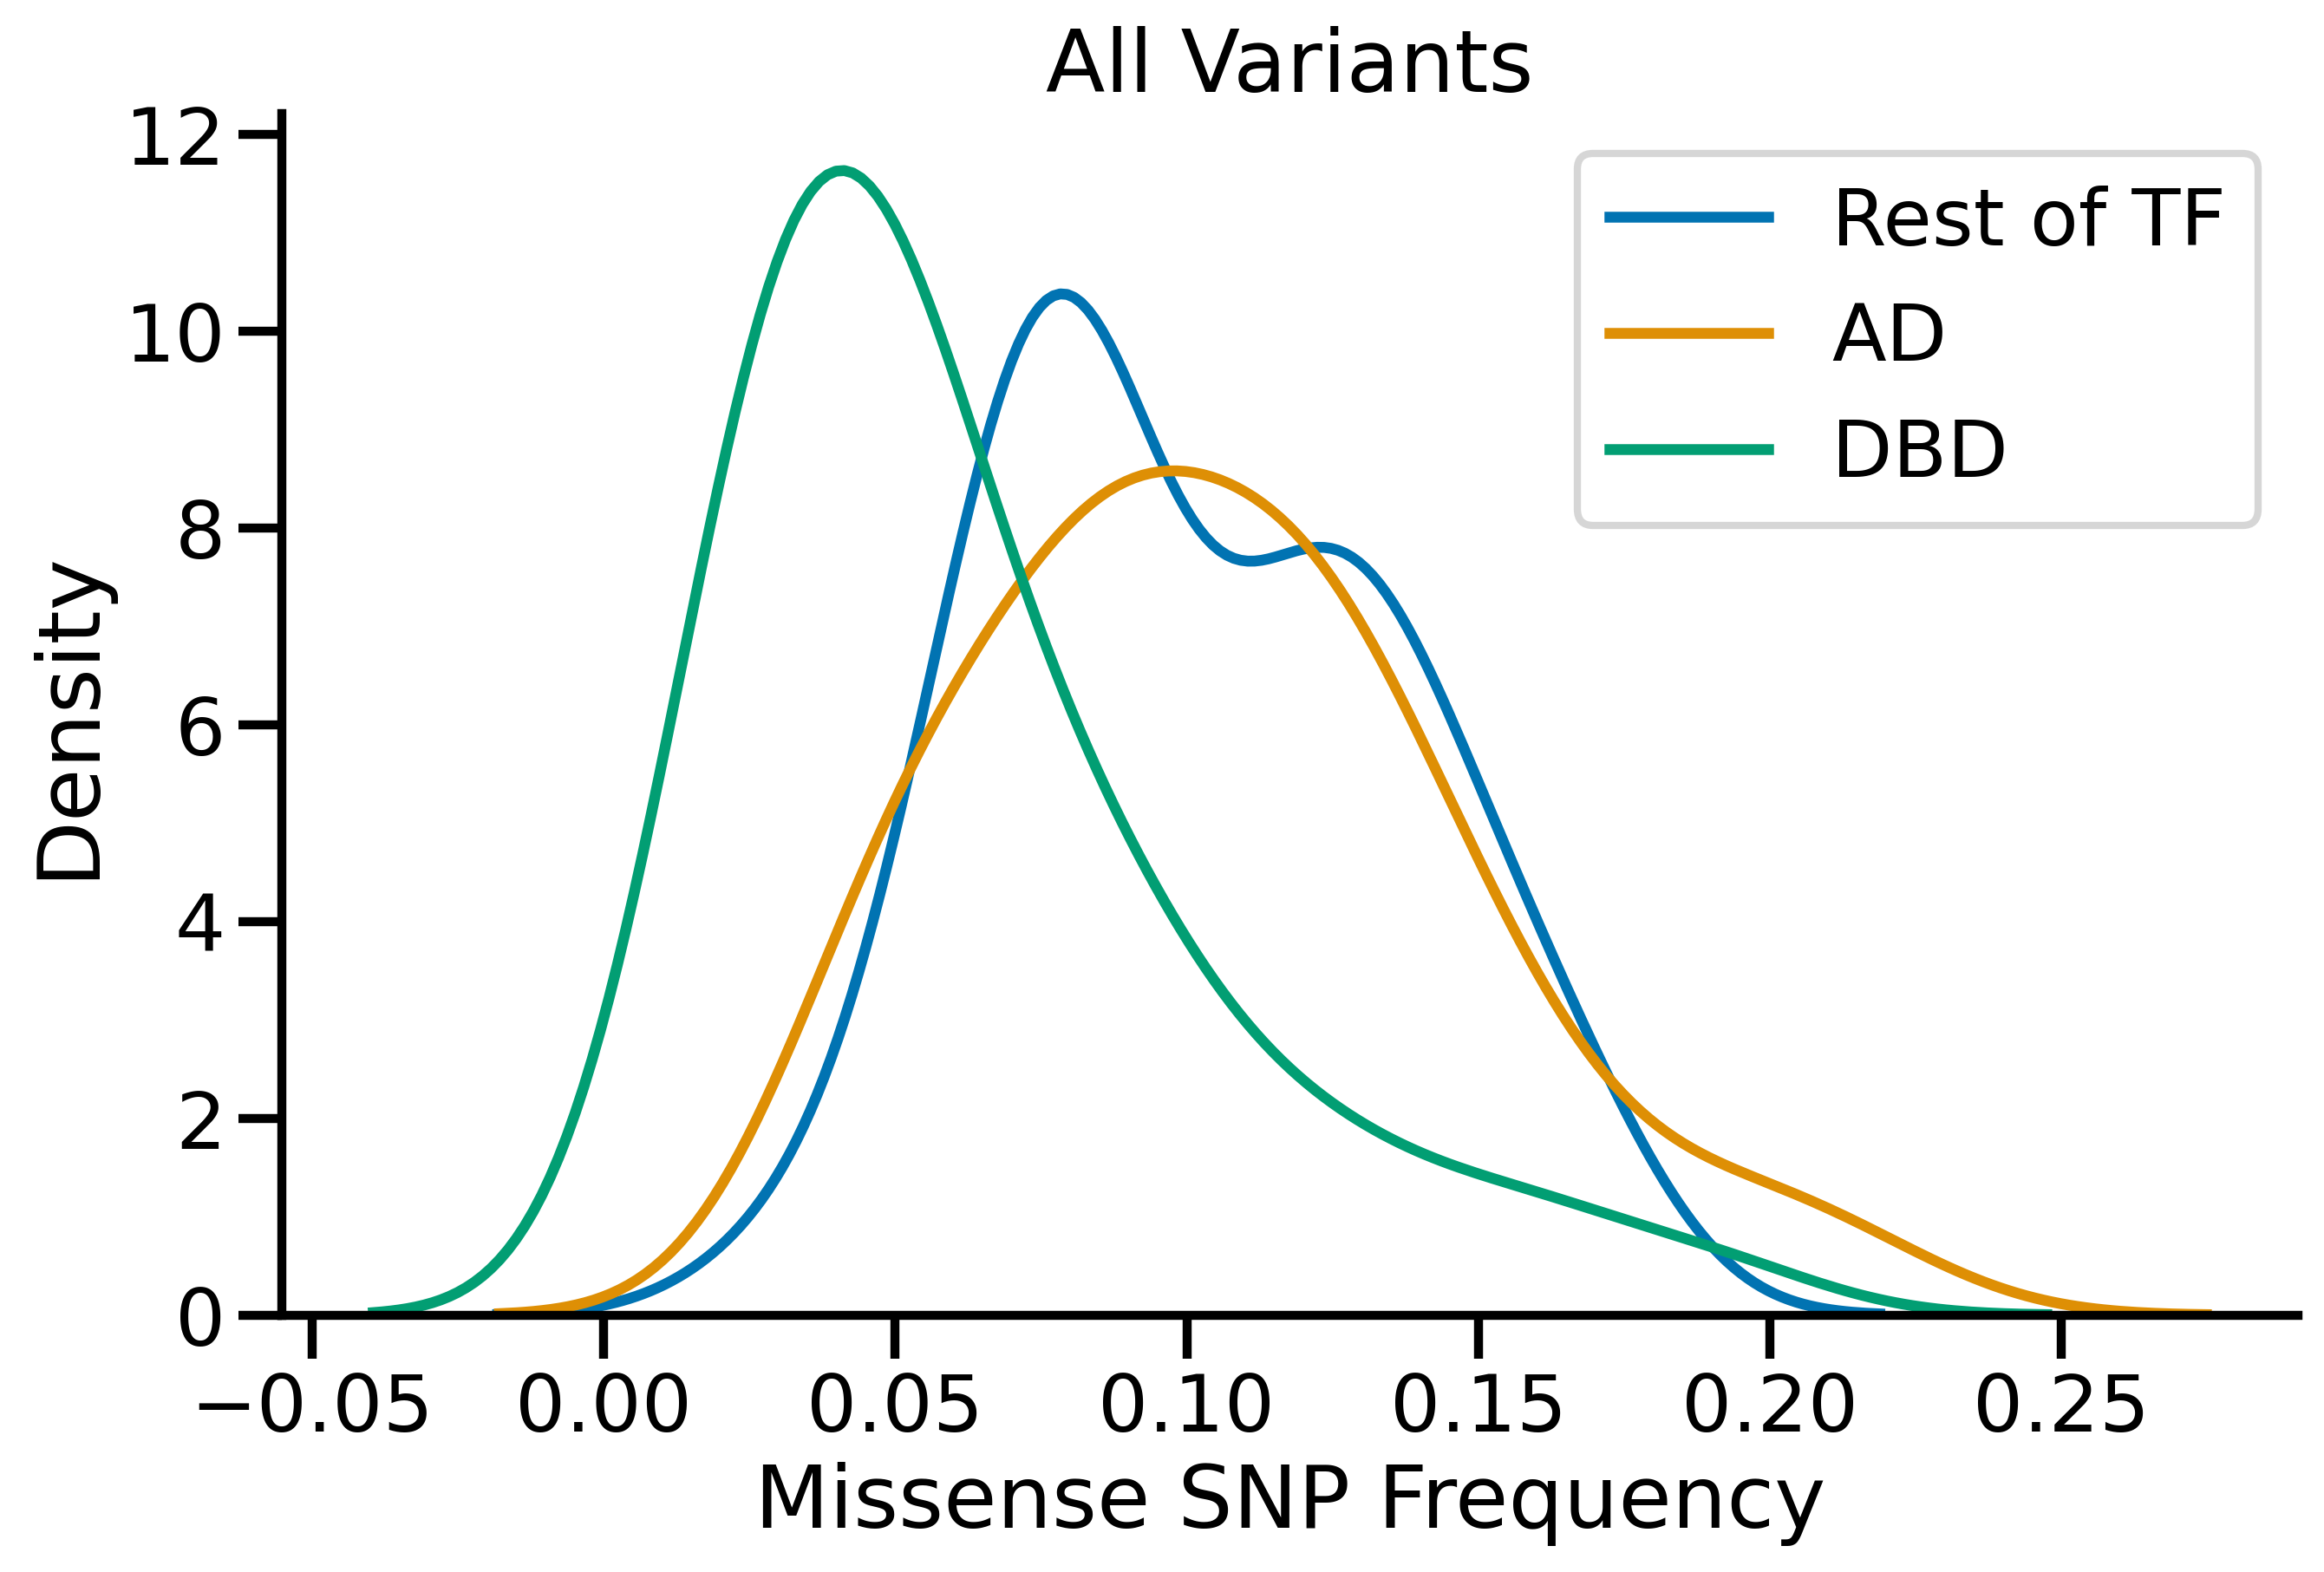

In [31]:
palette = sns.color_palette('colorblind')
sns.set_context('poster')
plt.figure(figsize = (10, 6), dpi = 300)


rest_of_TF_prop = (output["TF_missense"] - output["AD_missense"]) \
/ (output["TF_cds_length"] - output["AD_cds_length"])

sns.kdeplot(rest_of_TF_prop, label = "Rest of TF", color = palette[0]);
sns.kdeplot(output["AD_missense_prop"], color = palette[1], label = "AD");
sns.kdeplot(output["DBD_missense_prop"], color = palette[2], label = "DBD");


plt.legend()
plt.xlabel("Missense SNP Frequency")
plt.title("All Variants")
sns.despine()

In [32]:
for gene in set(contains_DBD_sig["gene-symbol"]) | set(sig_output["gene-symbol"]):
    print(gene)

IKZF1
PITX1
KLF7
MEIS2
CASZ1
ARX
CAMTA2
KDM5B
ERG
NR1D1
NCOA1
PAX6
KLF16
TCF7L2
TFE3
NKX2-2
MTF1
MYT1L
PAX5
HIVEP3
OTX1
NR4A2
RORA
YY1


In [33]:
set(contains_DBD_sig["gene-symbol"]) | set(sig_output["gene-symbol"])

{'ARX',
 'CAMTA2',
 'CASZ1',
 'ERG',
 'HIVEP3',
 'IKZF1',
 'KDM5B',
 'KLF16',
 'KLF7',
 'MEIS2',
 'MTF1',
 'MYT1L',
 'NCOA1',
 'NKX2-2',
 'NR1D1',
 'NR4A2',
 'OTX1',
 'PAX5',
 'PAX6',
 'PITX1',
 'RORA',
 'TCF7L2',
 'TFE3',
 'YY1'}

In [34]:
len(set(contains_DBD_sig["gene-symbol"]) | set(sig_output["gene-symbol"]))

24

In [35]:
set(hit_genes) - (set(contains_DBD_sig["gene-symbol"]) | set(sig_output["gene-symbol"]))

NameError: name 'hit_genes' is not defined

In [36]:
hit_genes = [
    "TFE3", "CASZ1", "CAMTA2", "ARNT2", "YY1", "ERG", "PAX5", "MEIS2", "ESR2",
    "NR1D1", "OTX1", "PITX1", "RORA", "HIVEP3", "NKX2-2", "PAX6", "KLF7",
    "NR4A2", "AR", "KDM5B", "GLIS1", "ARX", "TCF7L2", "EGR3", "MYT1L",
    "MTF1", "IKZF1", "KLF16"
]


In [37]:
new_hit_genes = set(contains_DBD_sig["gene-symbol"]) | set(sig_output["gene-symbol"])

In [38]:
known_ADs = pd.read_csv("../../output/known_ADs_considering_isoforms_and_canonical.csv")
hit_gene_ADs = known_ADs[known_ADs["Gene"].isin(new_hit_genes)]
hit_gene_ADs = hit_gene_ADs[~hit_gene_ADs["uniprotID"].str.contains("-")]
hit_gene_ADs["AD Length"] = hit_gene_ADs["ProteinRegionSeq"].str.len()
hit_gene_ADs[["Gene", "AD Length"]].groupby("Gene")["AD Length"].apply(list).reset_index()

,Gene,AD Length
0,ARX,[91]
1,CAMTA2,"[184, 110]"
2,CASZ1,[155]
3,ERG,"[47, 144]"
4,HIVEP3,[864]
5,IKZF1,[82]
6,KDM5B,[90]
7,KLF16,[44]
8,KLF7,[100]
9,MEIS2,[138]


# Summary

In [39]:
summary = output[["gene-symbol"]]
summary["AD_vs_TF_sig"] = summary["gene-symbol"].isin(sig_output["gene-symbol"])
summary["AD_vs_DBD_sig"] = summary["gene-symbol"].isin(contains_DBD_sig["gene-symbol"])
summary

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_92037/2989340729.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary["AD_vs_TF_sig"] = summary["gene-symbol"].isin(sig_output["gene-symbol"])
/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_92037/2989340729.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary["AD_vs_DBD_sig"] = summary["gene-symbol"].isin(contains_DBD_sig["gene-symbol"])


,gene-symbol,AD_vs_TF_sig,AD_vs_DBD_sig
0,ARNT2,False,False
1,ARX,False,True
2,AR,False,False
3,CASZ1,True,True
4,CC2D1A,False,False
5,CAMTA2,False,True
6,EBF3,False,False
7,EGR3,False,False
8,ESR2,False,False
9,GLIS1,False,False


In [40]:
summary[summary["AD_vs_TF_sig"] | summary["AD_vs_DBD_sig"]]

,gene-symbol,AD_vs_TF_sig,AD_vs_DBD_sig
1,ARX,False,True
3,CASZ1,True,True
5,CAMTA2,False,True
10,ERG,False,True
11,HIVEP3,False,True
12,IKZF1,False,True
13,KDM5B,False,True
14,KLF16,False,True
15,KLF7,False,True
18,MEIS2,True,True


In [41]:
summary.to_csv("../../output/iWES_v2_enrich_analysis.csv", index=False)

In [42]:
summary[summary["AD_vs_TF_sig"] | summary["AD_vs_DBD_sig"]].sort_values(by = ['AD_vs_TF_sig', 'AD_vs_DBD_sig', 'gene-symbol'], ascending=[False, False, True]).to_csv("../../output/iWES_v2_enrich_analysis_sig.csv", index=False)